# Chapter 4 — SIS Model (Recovery)
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

We build the **SIS (Susceptible → Infected → Susceptible)** model from Section 4.5.  
This extends the SI model with one crucial new mechanism: **recovery**.

At each time step, infected agents have a probability γ of recovering and  
returning to the **susceptible** state where they can be infected again later.

Key new behaviors compared to the SI model:
- The population **never reaches full infection** — a dynamic equilibrium emerges
- The equilibrium infection rate is determined analytically by **I/N = 1 − γ/τ** (Eq. 4.13)
- The simulation **stops** when either everyone is infected OR no one is infected (failed outbreak)

### Important implementation detail from the book

The book highlights a subtle ordering issue: infection and recovery must happen in  
separate passes to prevent an agent from being infected and recovering **within the same tick**.  
The solution is to restrict recovery to agents who are **both** `infected = True` **and**  
already colored red meaning they were infected in a *previous* step, not the current one.  
We implement this same logic in Python using a separate `newly_infected` flag.


---
## 1. Imports and Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mesa import Agent, Model
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector

np.random.seed(42)
print("All imports successful.")


All imports successful.


---
## 2. The Agent Class

The SIS agent has three responsibilities each time step, executed in this order:
1. **Try to become infected** (if susceptible) — same formula as the SI model
2. **Try to recover** (if infected *and* not newly infected this step)
3. **Move** — same correlated random walk as before

### The ordering problem and its solution

Suppose an agent becomes infected at step *t*. If we immediately allow it to recover  
in the same step, it could flip back to susceptible before it ever had a chance to  
infect any neighbors. This is biologically wrong and distorts the dynamics.

The book's solution: only agents who were **already infected at the start of the step**  
(i.e., infected in a previous step) are eligible for recovery.

We track this with an agent-level boolean flag: `newly_infected`.  
- When an agent becomes infected, `newly_infected = True`  
- At the start of the *next* step, it is cleared to `False`  
- Recovery is only allowed when `infected = True` AND `newly_infected = False`

### Variable types
| Variable | Type | Description |
|---|---|---|
| `self.infected` | Agent-level | Whether this agent is currently infected |
| `self.newly_infected` | Agent-level | True only during the step the agent was just infected |
| `self.heading` | Agent-level | Current movement direction (radians) |


In [2]:
class SISAgent(Agent):
    """
    A single agent in the SIS contagion model.

    Agent-level variables:
        infected        (bool) -- True if currently infected
        newly_infected  (bool) -- True only during the step of infection;
                                   prevents same-step recovery
        heading         (float) -- Current movement direction in radians
    """

    def __init__(self, model):
        super().__init__(model)

        # AGENT VARIABLE: infection status — all agents start susceptible
        self.infected = False

        # AGENT VARIABLE: newly_infected flag
        # This is the key mechanism preventing same-step infection + recovery.
        # It is set to True when an agent becomes infected, and cleared at the
        # start of the NEXT step before any other logic runs.
        self.newly_infected = False

        # AGENT VARIABLE: movement heading — random initial direction
        self.heading = self.random.uniform(0, 2 * np.pi)

    def step(self):
        # Step 1: Clear the newly_infected flag from the previous step.
        # This must happen FIRST, before infection or recovery checks,
        # so that any agent infected last step is now eligible for recovery.
        self.newly_infected = False

        # Step 2: If susceptible, try to become infected via neighbors or spontaneously
        self._try_infection()

        # Step 3: If infected AND not newly infected this step, try to recover
        self._try_recovery()

        # Step 4: Move
        self._move()

    # ------------------------------------------------------------------
    # INFECTION — identical formula to the SI model
    # ------------------------------------------------------------------
    def _try_infection(self):
        """
        Combined infection probability from social influence + spontaneous adoption:

            Pr(infection) = 1 - (1 - tau)^n * (1 - alpha)

        where n = number of infected neighbors within infection_radius.
        """
        if self.infected:
            return  # already infected — skip

        # LOCAL VARIABLE: neighbors — all agents within infection radius
        neighbors = self.model.space.get_neighbors(
            self.pos, self.model.infection_radius, include_center=False
        )

        # LOCAL VARIABLE: n_infected — count of infected neighbors
        n_infected = sum(1 for nb in neighbors if nb.infected)

        # LOCAL VARIABLES: probability components
        p_escape_neighbors   = (1 - self.model.tau) ** n_infected
        p_escape_spontaneous = (1 - self.model.alpha)
        p_infection = 1 - (p_escape_neighbors * p_escape_spontaneous)

        if self.random.random() < p_infection:
            self.infected = True
            # Mark as newly infected so recovery is blocked this step
            self.newly_infected = True

    # ------------------------------------------------------------------
    # RECOVERY — the new mechanism in the SIS model
    # ------------------------------------------------------------------
    def _try_recovery(self):
        """
        Infected agents recover with probability gamma (recovery_rate) per step,
        returning to the susceptible state.

        IMPORTANT: recovery is blocked if the agent was infected THIS step
        (newly_infected = True). This prevents same-step infection + recovery,
        which would distort the dynamics by not allowing newly infected agents
        any time to infect their neighbors.
        """
        # Only eligible for recovery if: infected AND was already infected
        # at the START of this step (not just infected a moment ago)
        if self.infected and not self.newly_infected:
            if self.random.random() < self.model.gamma:
                self.infected = False   # recover: return to susceptible state

    # ------------------------------------------------------------------
    # MOVEMENT — same correlated random walk as before
    # ------------------------------------------------------------------
    def _move(self):
        """Nudge heading, then step forward. Toroidal wrapping via Mesa."""
        # LOCAL VARIABLE: max_turn — half the turning angle in radians
        max_turn = np.radians(self.model.turning_angle) / 2
        self.heading += self.random.uniform(-max_turn, max_turn)

        dx = self.model.speed * np.cos(self.heading)
        dy = self.model.speed * np.sin(self.heading)

        self.model.space.move_agent(self, (self.pos[0] + dx, self.pos[1] + dy))


---
## 3. The Model Class

One new global parameter compared to the SI model: **γ (gamma)**, the recovery rate.

The stop condition also changes: the simulation stops when **either**:
- Everyone is infected (complete saturation — unlikely with recovery), OR
- No one is infected (failed/extinct outbreak)

Unlike the SI model, the SIS model typically settles into a **dynamic equilibrium**  
where neither of these extremes is reached — it just keeps running indefinitely.  
We therefore also set a `max_steps` limit.

### Variable types
| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_infected` | Global | Number of seed infections at t=0 |
| `tau` | Global | Transmissibility τ (per-contact infection probability) |
| `gamma` | Global | Recovery rate γ (probability of recovering per step) |
| `alpha` | Global | Spontaneous infection rate α (default 0) |
| `infection_radius` | Global | Spatial radius for neighbor detection |
| `speed` | Global | Movement distance per step |
| `turning_angle` | Global | Maximum heading change per step (degrees) |


In [4]:
class SISModel(Model):
    """
    The SIS contagion model with recovery.

    Global parameters:
        N                (int)   -- total number of agents
        init_infected    (int)   -- number of seed infections at t=0
        tau              (float) -- transmissibility (per-contact infection probability)
        gamma            (float) -- recovery rate (probability of recovering per step)
        alpha            (float) -- spontaneous infection rate (default 0)
        infection_radius (float) -- spatial radius for neighbor detection
        speed            (float) -- movement distance per step
        turning_angle    (float) -- max heading change per step, in degrees
        width, height    (float) -- size of the 2-D toroidal space
    """

    def __init__(
        self,
        N=300,
        init_infected=3,
        tau=0.1,
        gamma=0.02,
        alpha=0.0,
        infection_radius=1.0,
        speed=0.5,
        turning_angle=60,
        width=33,
        height=33,
    ):
        super().__init__()

        # ── GLOBAL VARIABLES ──────────────────────────────────────────
        self.N = N
        self.init_infected = init_infected
        self.tau = tau                  # transmissibility (τ)
        self.gamma = gamma              # recovery rate (γ)
        self.alpha = alpha              # spontaneous infection rate (α)
        self.infection_radius = infection_radius
        self.speed = speed
        self.turning_angle = turning_angle
        self.running = True

        # ── SPACE ─────────────────────────────────────────────────────
        self.space = ContinuousSpace(width, height, torus=True)

        # ── CREATE AND PLACE AGENTS ───────────────────────────────────
        for _ in range(self.N):
            agent = SISAgent(self)
            x = self.random.uniform(0, width)
            y = self.random.uniform(0, height)
            self.space.place_agent(agent, (x, y))

        # ── SEED INITIAL INFECTIONS ───────────────────────────────────
        n_seed = min(self.init_infected, self.N)
        seeds = list(self.agents)[:n_seed]
        for agent in seeds:
            agent.infected = True
            # Seed agents are treated as already-established infections
            # (not newly infected), so they are eligible for recovery from step 1
            agent.newly_infected = False

        # ── DATA COLLECTOR ────────────────────────────────────────────
        self.datacollector = DataCollector(
            model_reporters={
                "proportion_infected": lambda m: sum(
                    1 for a in m.agents if a.infected
                ) / m.N,
                # Also track the raw count for stop-condition checking
                "n_infected": lambda m: sum(1 for a in m.agents if a.infected),
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """
        One time step: activate all agents in random order, collect data,
        then check stop conditions.

        Stop conditions (matching the book):
          - Everyone is infected (complete saturation)
          - No one is infected (the outbreak died out)
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

        # LOCAL VARIABLE: n_infected — current number of infected agents
        n_infected = sum(1 for a in self.agents if a.infected)
        if n_infected == self.N or n_infected == 0:
            self.running = False

    def run(self, max_steps=5000):
        """Run up to max_steps steps. Returns a pandas DataFrame of recorded data."""
        for _ in range(max_steps):
            if not self.running:
                break
            self.step()
        return self.datacollector.get_model_vars_dataframe()


---
## 4. The Analytical SIS Model

### The difference equation (Eq. 4.9)

Adding recovery to the SI difference equation gives:

$$I_{t+1} = I_t + \tau I_t\left(1 - \frac{I_t}{N}\right) - \gamma I_t$$

The new term $-\gamma I_t$ subtracts the agents who recover each step.

### The equilibrium (Eq. 4.13)

At equilibrium, $\Delta I = 0$, which yields:

$$\frac{I^*}{N} = 1 - \frac{\gamma}{\tau}$$

This is the **proportion of the population that will remain infected** at steady state.  
Note that a positive equilibrium only exists when $\tau > \gamma$ (i.e., $R_0 = \tau/\gamma > 1$).  
If $\gamma \geq \tau$, the infection dies out entirely.

### R₀ (Eq. 4.17)

$$R_0 = \frac{\tau}{\gamma}$$

The infection spreads if and only if $R_0 > 1$.

### Variables
| Variable | Type | Description |
|---|---|---|
| `N` | Parameter | Total population |
| `tau` | Parameter | Transmissibility |
| `gamma` | Parameter | Recovery rate |
| `I0` | Parameter | Initial infected count |
| `n_steps` | Parameter | Steps to compute |
| `I` | Local | List of I_t values over time |
| `equilibrium` | Local | Analytical equilibrium proportion I*/N |


In [5]:
def analytical_SIS(N, tau, gamma, I0, n_steps):
    """
    Numerically solves the SIS difference equation (Eq. 4.9):

        I_{t+1} = I_t + tau * I_t * (1 - I_t/N) - gamma * I_t

    Parameters
    ----------
    N       : int   -- total population size
    tau     : float -- transmissibility
    gamma   : float -- recovery rate
    I0      : int   -- initial number of infected agents
    n_steps : int   -- number of time steps to compute

    Returns
    -------
    proportion  : np.ndarray  -- I_t / N at each step (length n_steps+1)
    equilibrium : float       -- analytical equilibrium I*/N from Eq. 4.13
                                 (clamped to [0, 1]; returns 0 if gamma >= tau)
    """
    I = [I0]

    for t in range(n_steps):
        # LOCAL VARIABLE: I_t — current infected count
        I_t = I[-1]

        # New infections: same as SI model — social spread
        new_infections = tau * I_t * (1 - I_t / N)

        # Recoveries: a proportion gamma of infected agents recover each step
        recoveries = gamma * I_t

        # Net change = new infections minus recoveries
        I_next = I_t + new_infections - recoveries

        # Clamp to [0, N] — numerical precision can push values slightly outside
        I_next = max(0.0, min(float(N), I_next))
        I.append(I_next)

    proportion = np.array(I) / N

    # Analytical equilibrium from Eq. 4.13: I*/N = 1 - gamma/tau
    # Only valid when tau > gamma (R0 > 1); otherwise the infection dies out
    if tau > gamma:
        equilibrium = 1 - gamma / tau
    else:
        equilibrium = 0.0   # infection cannot persist — dies out

    return proportion, equilibrium


def R0(tau, gamma):
    """Basic reproduction number: R0 = tau / gamma."""
    return tau / gamma


# ── Sanity check ─────────────────────────────────────────────────────────────
prop, eq = analytical_SIS(N=300, tau=0.1, gamma=0.02, I0=3, n_steps=500)
print(f"Analytical SIS (N=300, τ=0.1, γ=0.02):")
print(f"  R₀ = τ/γ = {R0(0.1, 0.02):.2f}  (> 1 → infection persists)")
print(f"  Equilibrium I*/N = 1 - γ/τ = {eq:.3f}  ({eq*100:.1f}% of population)")
print(f"  Proportion infected at t=500: {prop[500]:.3f}  (should match equilibrium)")


Analytical SIS (N=300, τ=0.1, γ=0.02):
  R₀ = τ/γ = 5.00  (> 1 → infection persists)
  Equilibrium I*/N = 1 - γ/τ = 0.800  (80.0% of population)
  Proportion infected at t=500: 0.800  (should match equilibrium)


---
## 5. Run the Agent-Based Simulation

**Default parameters** (matching the book's SIS model defaults):

| Parameter | Value | Notes |
|---|---|---|
| N | 300 | Population size |
| init_infected | 3 | Three seed infections |
| τ (tau) | 0.1 | Transmissibility per contact |
| γ (gamma) | 0.02 | Recovery rate — expected infection duration = 1/γ = 50 steps |
| α (alpha) | 0.0 | No spontaneous adoption |
| infection_radius | 1.0 | Spatial radius for neighbor detection |
| speed | 0.5 | Distance per step |
| turning_angle | 60° | Moderate movement correlation |

With these parameters: $R_0 = 0.1 / 0.02 = 5.0 > 1$ → infection persists.  
Predicted equilibrium: $I^*/N = 1 - 0.02/0.1 = 0.80$ (80% of population infected at steady state).


In [6]:
# ── GLOBAL PARAMETERS ────────────────────────────────────────────────────────
N                = 300
init_infected    = 3
tau              = 0.1
gamma            = 0.02
alpha            = 0.0
infection_radius = 1.0
speed            = 0.5
turning_angle    = 60

print(f"Parameters: τ={tau}, γ={gamma}")
print(f"R₀ = τ/γ = {R0(tau, gamma):.2f}")
print(f"Predicted equilibrium I*/N = {1 - gamma/tau:.3f} ({(1 - gamma/tau)*100:.1f}%)")
print()

# ── RUN ───────────────────────────────────────────────────────────────────────
print("Running SIS agent-based simulation...")
model = SISModel(
    N=N,
    init_infected=init_infected,
    tau=tau,
    gamma=gamma,
    alpha=alpha,
    infection_radius=infection_radius,
    speed=speed,
    turning_angle=turning_angle,
)
sim_data = model.run(max_steps=5000)

n_steps_sim = len(sim_data) - 1
final_prop = sim_data["proportion_infected"].iloc[-1]
print(f"Simulation ran for {n_steps_sim} steps.")
print(f"Final proportion infected: {final_prop:.3f}")


Parameters: τ=0.1, γ=0.02
R₀ = τ/γ = 5.00
Predicted equilibrium I*/N = 0.800 (80.0%)

Running SIS agent-based simulation...
Simulation ran for 5000 steps.
Final proportion infected: 0.737


---
## 6. Plot: Simulation vs. Analytical Prediction

We overlay three things:
- **Red line** — agent-based simulation (proportion infected over time)
- **Grey line** — analytical prediction from Eq. 4.9
- **Dashed blue line** — analytical equilibrium $I^*/N = 1 - \gamma/\tau$

The simulation will oscillate around the equilibrium rather than settling cleanly onto it —  
this is the stochastic spatial clustering effect described in Section 4.5.1 (Figure 4.11).  
The analytical model predicts the *average* the simulation fluctuates around.


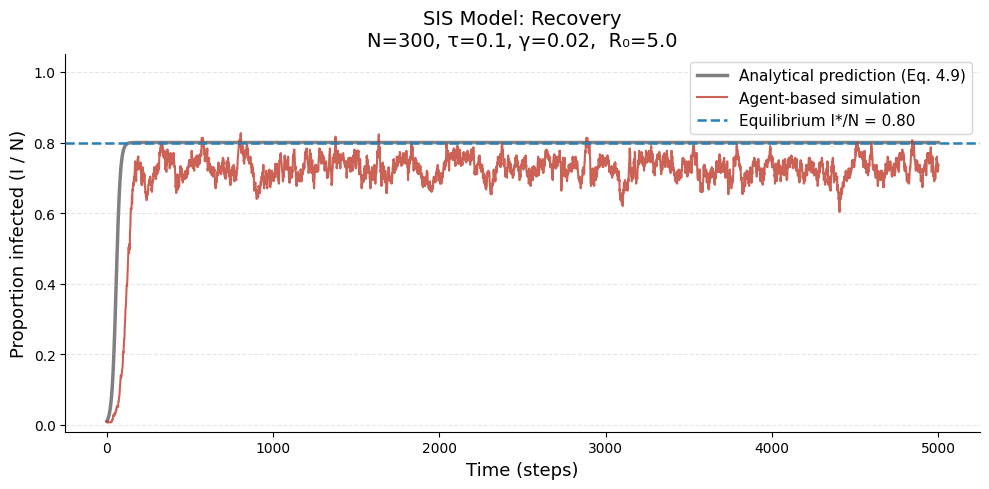

In [7]:
# Compute analytical curve for the same number of steps
analytical, equilibrium = analytical_SIS(N, tau, gamma, init_infected, n_steps_sim)

fig, ax = plt.subplots(figsize=(10, 5))

time_steps = np.arange(n_steps_sim + 1)

# Analytical prediction (grey)
ax.plot(
    time_steps, analytical,
    color="grey", linewidth=2.5,
    label="Analytical prediction (Eq. 4.9)", zorder=1,
)

# Simulation output (red)
ax.plot(
    time_steps, sim_data["proportion_infected"].values,
    color="#c0392b", linewidth=1.5, alpha=0.8,
    label="Agent-based simulation", zorder=2,
)

# Equilibrium line (dashed blue)
ax.axhline(
    equilibrium, color="#2980b9", linewidth=1.8,
    linestyle="--", label=f"Equilibrium I*/N = {equilibrium:.2f}", zorder=3,
)

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title(
    f"SIS Model: Recovery\n"
    f"N={N}, τ={tau}, γ={gamma},  R₀={R0(tau, gamma):.1f}",
    fontsize=14,
)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Parameter Exploration: Effect of γ (Recovery Rate)

This replicates Figure 4.10 from the book.  

As γ increases (faster recovery):
- The **equilibrium infection level drops** — fewer people are infected at steady state
- The system takes **longer to reach equilibrium** — individuals cycle faster through infection
- When γ ≥ τ, **R₀ drops below 1** and the infection dies out entirely

We plot analytical curves only here (faster to compute), with dashed equilibrium lines.


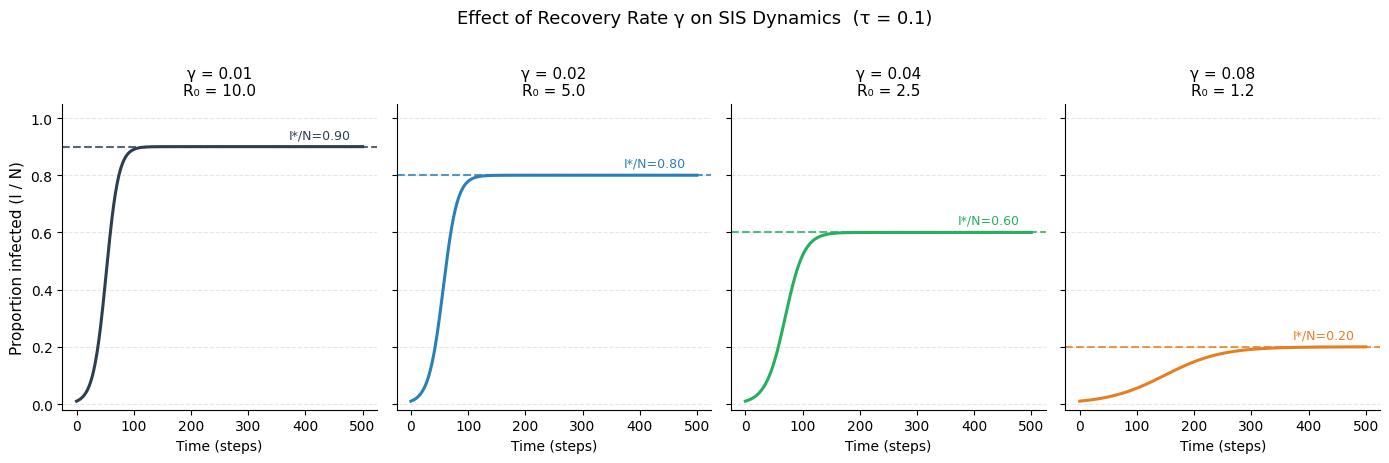

In [8]:
# GLOBAL VARIABLE: gamma_values — recovery rates to explore
# tau is fixed at 0.1; we vary gamma to change R0
gamma_values = [0.01, 0.02, 0.04, 0.08]
colors_gamma  = ["#2c3e50", "#2980b9", "#27ae60", "#e67e22"]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(14, 4.5), sharey=True)

for ax, gamma_val, color in zip(axes, gamma_values, colors_gamma):
    # LOCAL VARIABLE: r0_val — R0 for this parameter combination
    r0_val = R0(tau, gamma_val)

    # Compute analytical curve and equilibrium
    prop, eq = analytical_SIS(N, tau, gamma_val, init_infected, n_steps=500)

    ax.plot(prop, color=color, linewidth=2.2)

    if eq > 0:
        ax.axhline(eq, color=color, linewidth=1.5, linestyle="--", alpha=0.8)
        ax.text(
            480, eq + 0.03, f"I*/N={eq:.2f}",
            color=color, fontsize=9, ha="right",
        )

    ax.set_title(f"γ = {gamma_val}\nR₀ = {r0_val:.1f}", fontsize=11)
    ax.set_xlabel("Time (steps)", fontsize=10)
    ax.set_ylim(-0.02, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Proportion infected (I / N)", fontsize=11)
fig.suptitle(f"Effect of Recovery Rate γ on SIS Dynamics  (τ = {tau})", fontsize=13, y=1.02)

plt.tight_layout()
plt.show()


---
## 8. R₀ and the Extinction Threshold

$R_0 = \tau / \gamma$ determines whether the infection persists or dies out.

We can visualize the **equilibrium infection rate** as a function of $R_0$ by sweeping  
the ratio γ/τ from above 1 (infection dies out) down to near 0 (infection saturates the population).

This plot illustrates a fundamental threshold property:
- When $R_0 < 1$: equilibrium = 0 (no infection)
- When $R_0 > 1$: equilibrium = $1 - 1/R_0$ (positive stable infection level)
- The transition at $R_0 = 1$ is a **phase transition** — a sharp qualitative change in system behavior


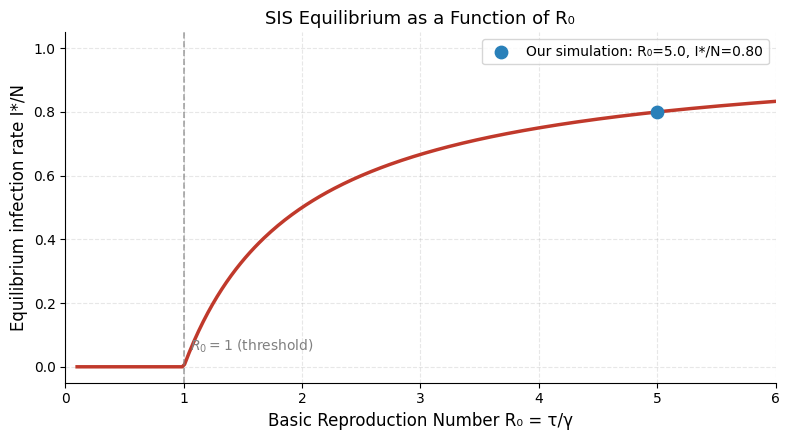

In [9]:
# LOCAL VARIABLE: R0_values — range of R0 values to sweep over
R0_values = np.linspace(0.1, 6.0, 300)

# LOCAL VARIABLE: equilibria — predicted I*/N for each R0 value
# When R0 <= 1: infection dies out, equilibrium = 0
# When R0 > 1:  equilibrium = 1 - 1/R0
equilibria = np.where(R0_values > 1, 1 - 1 / R0_values, 0.0)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(R0_values, equilibria, color="#c0392b", linewidth=2.5)

# Mark the R0 = 1 threshold
ax.axvline(1.0, color="grey", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(1.05, 0.05, "$R_0 = 1$ (threshold)", color="grey", fontsize=10)

# Mark our simulation's R0
r0_sim = R0(tau, gamma)
eq_sim = 1 - gamma / tau
ax.scatter([r0_sim], [eq_sim], color="#2980b9", s=80, zorder=5,
           label=f"Our simulation: R₀={r0_sim:.1f}, I*/N={eq_sim:.2f}")

ax.set_xlabel("Basic Reproduction Number R₀ = τ/γ", fontsize=12)
ax.set_ylabel("Equilibrium infection rate I*/N", fontsize=12)
ax.set_title("SIS Equilibrium as a Function of R₀", fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 6)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 9. Failed Outbreak: When R₀ < 1

When $R_0 < 1$ (γ > τ), the infection cannot sustain itself — each infected  
individual recovers before passing the infection to even one other person on average.  
The outbreak fizzles out.

We demonstrate this by running the model with γ > τ.


Parameters: τ=0.05, γ=0.1
R₀ = τ/γ = 0.50  (< 1 → infection should die out)
Simulation stopped after 38 steps.
Final proportion infected: 0.0000  (should be ~0.0)


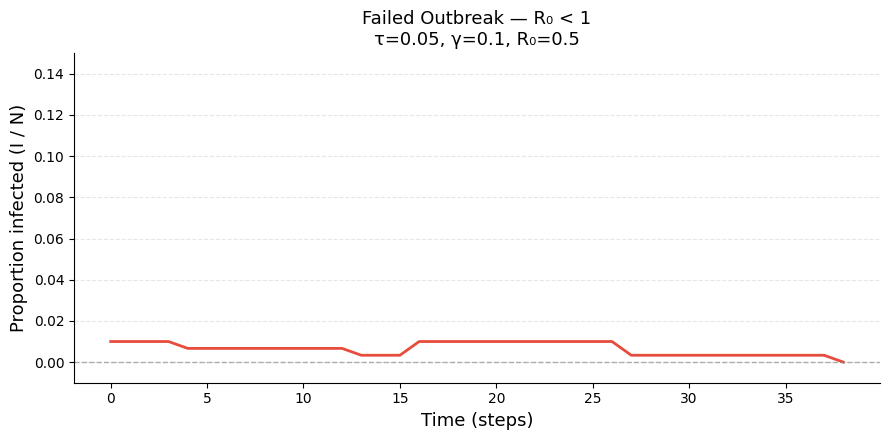

In [10]:
# Set gamma > tau so that R0 < 1 — infection should die out
tau_low   = 0.05
gamma_high = 0.1    # gamma > tau → R0 = 0.5 < 1

print(f"Parameters: τ={tau_low}, γ={gamma_high}")
print(f"R₀ = τ/γ = {R0(tau_low, gamma_high):.2f}  (< 1 → infection should die out)")

model_fail = SISModel(
    N=N,
    init_infected=init_infected,
    tau=tau_low,
    gamma=gamma_high,
    alpha=alpha,
    infection_radius=infection_radius,
    speed=speed,
    turning_angle=turning_angle,
)
data_fail = model_fail.run(max_steps=5000)

n_steps_fail = len(data_fail) - 1
final_fail = data_fail["proportion_infected"].iloc[-1]
print(f"Simulation stopped after {n_steps_fail} steps.")
print(f"Final proportion infected: {final_fail:.4f}  (should be ~0.0)")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    np.arange(n_steps_fail + 1),
    data_fail["proportion_infected"].values,
    color="#e74c3c", linewidth=2,
)
ax.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion infected (I / N)", fontsize=13)
ax.set_title(
    f"Failed Outbreak — R₀ < 1\n"
    f"τ={tau_low}, γ={gamma_high}, R₀={R0(tau_low, gamma_high):.1f}",
    fontsize=13,
)
ax.set_ylim(-0.01, 0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 10. Reflection and Key Takeaways

### What changed from the SI model

| Feature | SI Model | SIS Model |
|---|---|---|
| Recovery? | ❌ No | ✅ Yes → back to susceptible |
| Final state | 100% infected | Dynamic equilibrium at $1 - \gamma/\tau$ |
| Stops when? | Everyone infected | Everyone infected OR no one infected |
| New parameter | — | γ (recovery rate) |
| Key ratio | — | $R_0 = \tau / \gamma$ |

### The three big insights from this model

1. **Dynamic equilibrium, not saturation.**  
   Recovery prevents the population from ever becoming fully infected.  
   A fixed proportion remains infected indefinitely, even as individuals cycle through states.

2. **R₀ determines everything about the long-run outcome.**  
   Whether the infection persists at all, and at what level, depends entirely on $R_0 = \tau/\gamma$.  
   This is a powerful compression: two parameters collapse into one decisive number.

3. **ABM oscillates; analytical model is smooth.**  
   The analytical prediction is a clean curve converging to the equilibrium.  
   The ABM fluctuates around it due to spatial clustering and stochasticity.  
   Neither is "wrong" — they reveal different things about the same system.
